In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from sklearn.feature_extraction.text import CountVectorizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [64]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [65]:
import kagglehub

path = kagglehub.dataset_download(
   "kazanova/sentiment140"
)

# Load CSV
print("Dataset path:",path)
print(os.listdir(path))

Using Colab cache for faster access to the 'sentiment140' dataset.
Dataset path: /kaggle/input/sentiment140
['training.1600000.processed.noemoticon.csv']


In [66]:
import os
import pandas as pd

csv_file = os.path.join(path, "training.1600000.processed.noemoticon.csv")

df = pd.read_csv(csv_file, encoding="latin-1", header=None)


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   0       1600000 non-null  int64 
 1   1       1600000 non-null  int64 
 2   2       1600000 non-null  object
 3   3       1600000 non-null  object
 4   4       1600000 non-null  object
 5   5       1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [68]:
df.shape

(1600000, 6)

In [69]:
df.columns = ["Sentiment", "ID", "Date", "Query", "User", "Comment"]

In [70]:
print(df.columns)
df.head()

Index(['Sentiment', 'ID', 'Date', 'Query', 'User', 'Comment'], dtype='object')


,Sentiment,ID,Date,Query,User,Comment
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [71]:
df = df[["Comment", "Sentiment"]]

In [72]:
df["Sentiment"] = df["Sentiment"].replace({
    0: "Negative",
    4: "Positive"
})

In [73]:
df.head()

,Comment,Sentiment
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Negative
1,is upset that he can't update his Facebook by ...,Negative
2,@Kenichan I dived many times for the ball. Man...,Negative
3,my whole body feels itchy and like its on fire,Negative
4,"@nationwideclass no, it's not behaving at all....",Negative


In [74]:
df['Clean_Comment']=df['Comment'].apply(clean_text)

In [75]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [76]:
df['Sentiment'].value_counts()

,count
Sentiment,
Negative,800000
Positive,800000


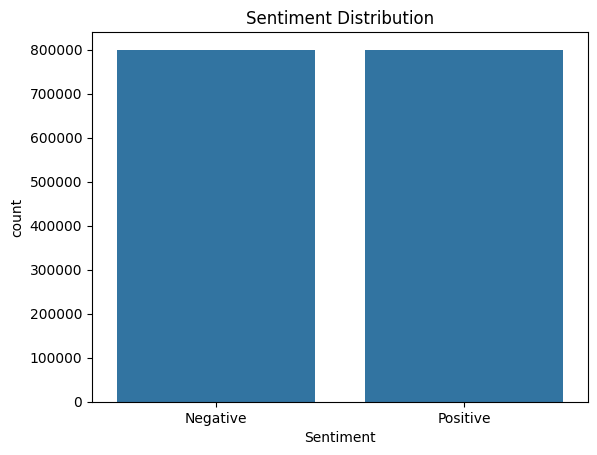

In [77]:
sns.countplot(x='Sentiment',data=df)
plt.title("Sentiment Distribution")
plt.show()

In [78]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [79]:
df["Clean_Comment"] = df["Comment"].apply(clean_text)

In [80]:
vectorizer=CountVectorizer(max_features=20)

X=vectorizer.fit_transform(df['Clean_Comment'])

words=vectorizer.get_feature_names_out()

counts=np.asarray(X.sum(axis=0)).flatten()

word_freq=pd.DataFrame({'Word':words,'Count':counts})

word_freq=word_freq.sort_values(by='Count',ascending=False)

print(word_freq)

      Word   Count
9       im  177567
2      day  104020
7     good   89537
4      get   85931
11    like   79097
5       go   77444
13    love   66964
3     dont   66939
19    work   66494
17   today   66107
6    going   64104
16    time   63795
1     cant   62621
8      got   60903
0     back   56119
14     one   55880
12     lol   55212
10    know   53224
15  really   49563
18    want   48315


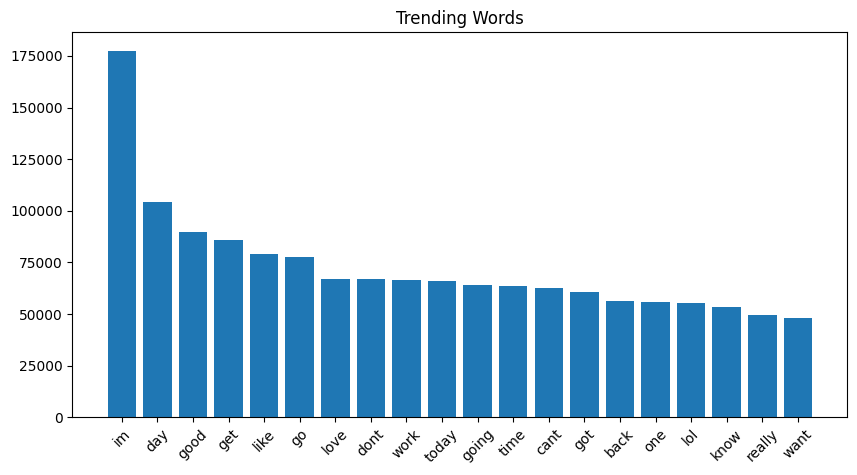

In [81]:
plt.figure(figsize=(10,5))

plt.bar(word_freq['Word'],word_freq['Count'])

plt.xticks(rotation=45)

plt.title("Trending Words")

plt.show()

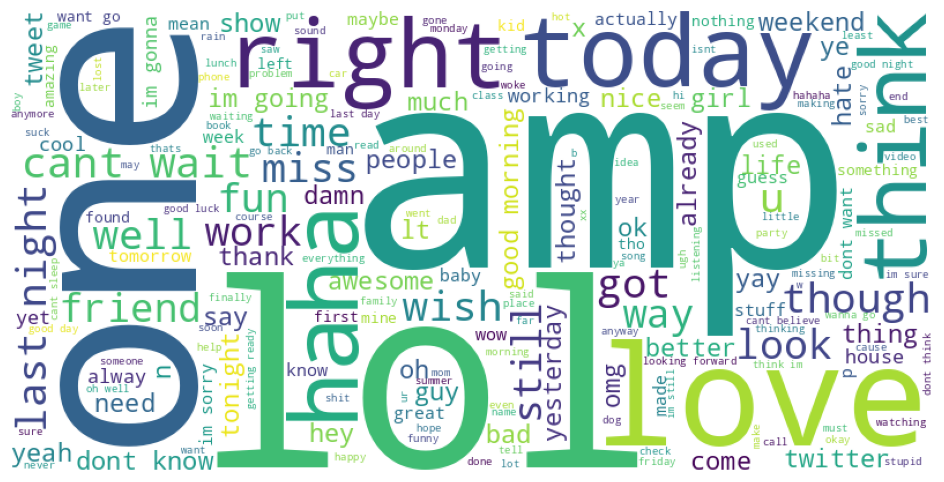

In [82]:
from wordcloud import WordCloud

text=" ".join(df['Clean_Comment'])

wc=WordCloud(width=800,height=400,background_color='white').generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wc)

plt.axis('off')

plt.show()

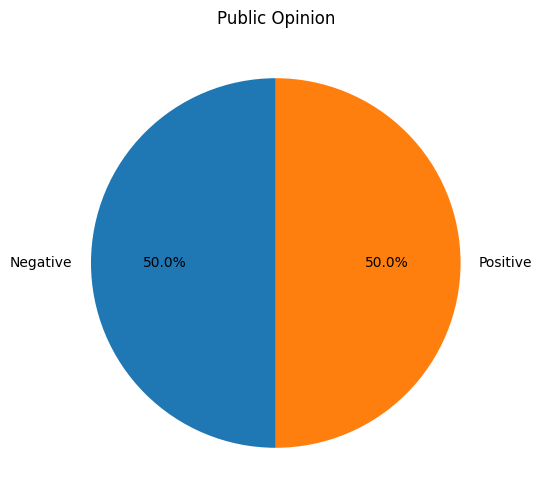

In [83]:
sentiment=df['Sentiment'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(sentiment,
        labels=sentiment.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Public Opinion")

plt.show()

In [84]:
positive=df[df['Sentiment']=="positive"]

positive[['Comment']].head(10)

,Comment


In [85]:
negative=df[df['Sentiment']=="negative"]

negative[['Comment']].head(10)

,Comment


In [86]:
df.to_csv("Cleaned_SocialMedia_Comments.csv",index=False)